# Spatial Context Benchmarking

This notebook measures how much spatial context OmniCloudMask needs to produce accurate cloud masks. The question: if you only need to classify a small area (32×32 pixels), does providing surrounding context improve accuracy?

**Method:**
1. For each scene in the CloudSEN12 High test set, extract center patches of increasing size (32–509 px)
2. Run OmniCloudMask on each patch
3. Evaluate only the center 32×32 pixels against the ground truth label
4. Repeat at different spatial resolutions (10m, 20m, 30m) by downsampling the native 10m imagery

This reveals how much extra context is needed at each resolution and where the accuracy gain plateaus.

In [1]:
import json
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
from scipy.ndimage import zoom
from sklearn.metrics import balanced_accuracy_score, f1_score
from tqdm.auto import tqdm

import omnicloudmask
from omnicloudmask import predict_from_array

## 1. Configuration

Set the dataset path, patch sizes to test, and resolution factors. The evaluation size is fixed at 32×32 pixels — this is the area we actually care about classifying. Larger patch sizes provide more surrounding context for the model.

In [2]:
DATASET_DIR = Path("/media/nick/4TB Working 7/Datasets/OCM datasets v3/CloudSEN12 test")
EVAL_SIZE = 32  # Center pixels to evaluate
PATCH_SIZES = [32, 48, 64, 96, 128, 192, 256, 320, 384, 448, 509]
RESOLUTION_FACTORS = {"10 m": 1, "20 m": 2, "30 m": 3, "40 m": 4, "50 m": 5}
CLASS_NAMES = {0: "Clear", 1: "Thick Cloud", 2: "Thin Cloud", 3: "Cloud Shadow"}
N_WORKERS = 4  # Threads for concurrent predict_from_array calls

# Discover scenes: pair each L2A image with its label
l2a_files = sorted(DATASET_DIR.glob("*_l2a.tif"))
scenes = []
for img_path in l2a_files:
    label_path = img_path.parent / img_path.name.replace("_image_l2a", "_label")
    if label_path.exists():
        scenes.append((img_path, label_path))

print(f"Found {len(scenes)} scenes")
print(f"Patch sizes: {PATCH_SIZES}")
print(f"Eval size: {EVAL_SIZE}\u00d7{EVAL_SIZE} pixels")
print(f"Resolutions: {list(RESOLUTION_FACTORS.keys())}")
print(f"Workers: {N_WORKERS}")

Found 975 scenes
Patch sizes: [32, 48, 64, 96, 128, 192, 256, 320, 384, 448, 509]
Eval size: 32×32 pixels
Resolutions: ['10 m', '20 m', '30 m', '40 m', '50 m']
Workers: 4


## 2. Helper functions

- `center_crop` extracts the center region from an array
- `downsample_image` simulates coarser resolutions
- `compute_metrics` calculates BOA and per-class Dice scores

In [3]:
def center_crop(arr: np.ndarray, crop_size: int) -> np.ndarray:
    """Extract center crop from array of shape (C, H, W) or (H, W)."""
    if arr.ndim == 3:
        _, h, w = arr.shape
        y0 = (h - crop_size) // 2
        x0 = (w - crop_size) // 2
        return arr[:, y0 : y0 + crop_size, x0 : x0 + crop_size]
    h, w = arr.shape
    y0 = (h - crop_size) // 2
    x0 = (w - crop_size) // 2
    return arr[y0 : y0 + crop_size, x0 : x0 + crop_size]


def downsample_image(arr: np.ndarray, factor: int) -> np.ndarray:
    """Downsample (C, H, W) array by integer factor using bilinear interpolation."""
    return zoom(arr, (1, 1 / factor, 1 / factor), order=1).astype(arr.dtype)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Compute BOA (balanced overall accuracy) and per-class Dice scores."""
    return {
        "boa": float(balanced_accuracy_score(y_true, y_pred)),
        "dice_per_class": {
            CLASS_NAMES[c]: float(v)
            for c, v in enumerate(
                f1_score(
                    y_true,
                    y_pred,
                    average=None,
                    labels=[0, 1, 2, 3],
                    zero_division=0,
                )
            )
        },
    }

## 3. Run experiment

For each resolution:
1. Pre-load all images and labels into memory (and downsample if needed)
2. For each patch size, run threaded `predict_from_array` calls across all scenes
3. Evaluate the center 32×32 pixels of each prediction

Pre-loading avoids re-reading images from disk for every patch size. Threading overlaps I/O and CPU preprocessing with GPU inference.

In [4]:
def predict_scene(
    img: np.ndarray,
    label_10m: np.ndarray,
    patch_size: int,
    eval_size: int,
    factor: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Crop, predict, and evaluate one scene. Thread-safe.

    Predictions at coarser resolutions are upsampled back to 10m
    so all resolutions are evaluated against the same 10m ground truth.
    """
    img_patch = center_crop(img, patch_size)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pred = predict_from_array(
            img_patch,
            patch_size=patch_size,
            patch_overlap=0,
            inference_dtype=torch.float16,
        )

    if factor > 1:
        # Upsample prediction back to 10m for fair comparison
        pred_10m = zoom(pred, (1, factor, factor), order=0)
        pred_center = center_crop(pred_10m[0], eval_size)
    else:
        pred_center = center_crop(pred[0], eval_size)

    label_center = center_crop(label_10m, eval_size)
    return pred_center.ravel(), label_center.ravel()


results = {}

for res_name, factor in RESOLUTION_FACTORS.items():
    print(f"\n{'=' * 60}")
    print(f"Resolution: {res_name} (downsample factor: {factor})")
    print(f"{'=' * 60}")

    # Pre-load all images (downsampled) and 10m labels into memory
    images: list[np.ndarray] = []
    labels_10m: list[np.ndarray] = []
    for img_path, label_path in tqdm(scenes, desc=f"Loading {res_name}"):
        with rasterio.open(img_path) as src:
            img = src.read()
        with rasterio.open(label_path) as src:
            label = src.read(1)
        labels_10m.append(label)
        if factor > 1:
            img = downsample_image(img, factor)
        images.append(img)

    effective_size = min(images[0].shape[1], images[0].shape[2])
    print(
        f"Loaded {len(images)} scenes, images at {effective_size}\u00d7{effective_size} px"
    )

    # Include the full downsampled image size so all resolutions
    # cover their maximum available ground distance
    patch_sizes = sorted(set(PATCH_SIZES + [effective_size]))

    # Evaluate each patch size with threaded predictions
    res_results = {}
    for patch_size in patch_sizes:
        if patch_size > effective_size:
            continue

        all_preds: list[np.ndarray] = []
        all_labels: list[np.ndarray] = []

        with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
            futures = {
                pool.submit(
                    predict_scene,
                    images[i],
                    labels_10m[i],
                    patch_size,
                    EVAL_SIZE,
                    factor,
                ): i
                for i in range(len(images))
            }
            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc=f"{res_name} {patch_size}px",
                leave=False,
            ):
                pred_flat, label_flat = future.result()
                all_preds.append(pred_flat)
                all_labels.append(label_flat)

        y_pred = np.concatenate(all_preds)
        y_true = np.concatenate(all_labels)
        metrics = compute_metrics(y_true, y_pred)
        res_results[patch_size] = metrics
        ctx_px = (patch_size - EVAL_SIZE) // 2
        print(f"  {patch_size:>4}px  ctx={ctx_px:>4}px  boa={metrics['boa']:.4f}")

    results[res_name] = res_results
    del images, labels_10m  # free memory before next resolution


Resolution: 10 m (downsample factor: 1)


Loading 10 m:   0%|          | 0/975 [00:00<?, ?it/s]

Loaded 975 scenes, images at 509×509 px


10 m 32px:   0%|          | 0/975 [00:00<?, ?it/s]

    32px  ctx=   0px  boa=0.5521


...

    64px  ctx=  16px  boa=0.7199


50 m 96px:   0%|          | 0/975 [00:00<?, ?it/s]

    96px  ctx=  32px  boa=0.7484


50 m 102px:   0%|          | 0/975 [00:00<?, ?it/s]

   102px  ctx=  35px  boa=0.7584


## 4. Visualise

Three plots:
1. **BOA** vs patch size (pixels) for each resolution
2. **BOA** vs patch edge length (metres) — lets users read off how large their input patch should be regardless of sensor
3. **Per-class Dice** vs patch size at 10m resolution

Written: ../docs/_static/spatial_context.png


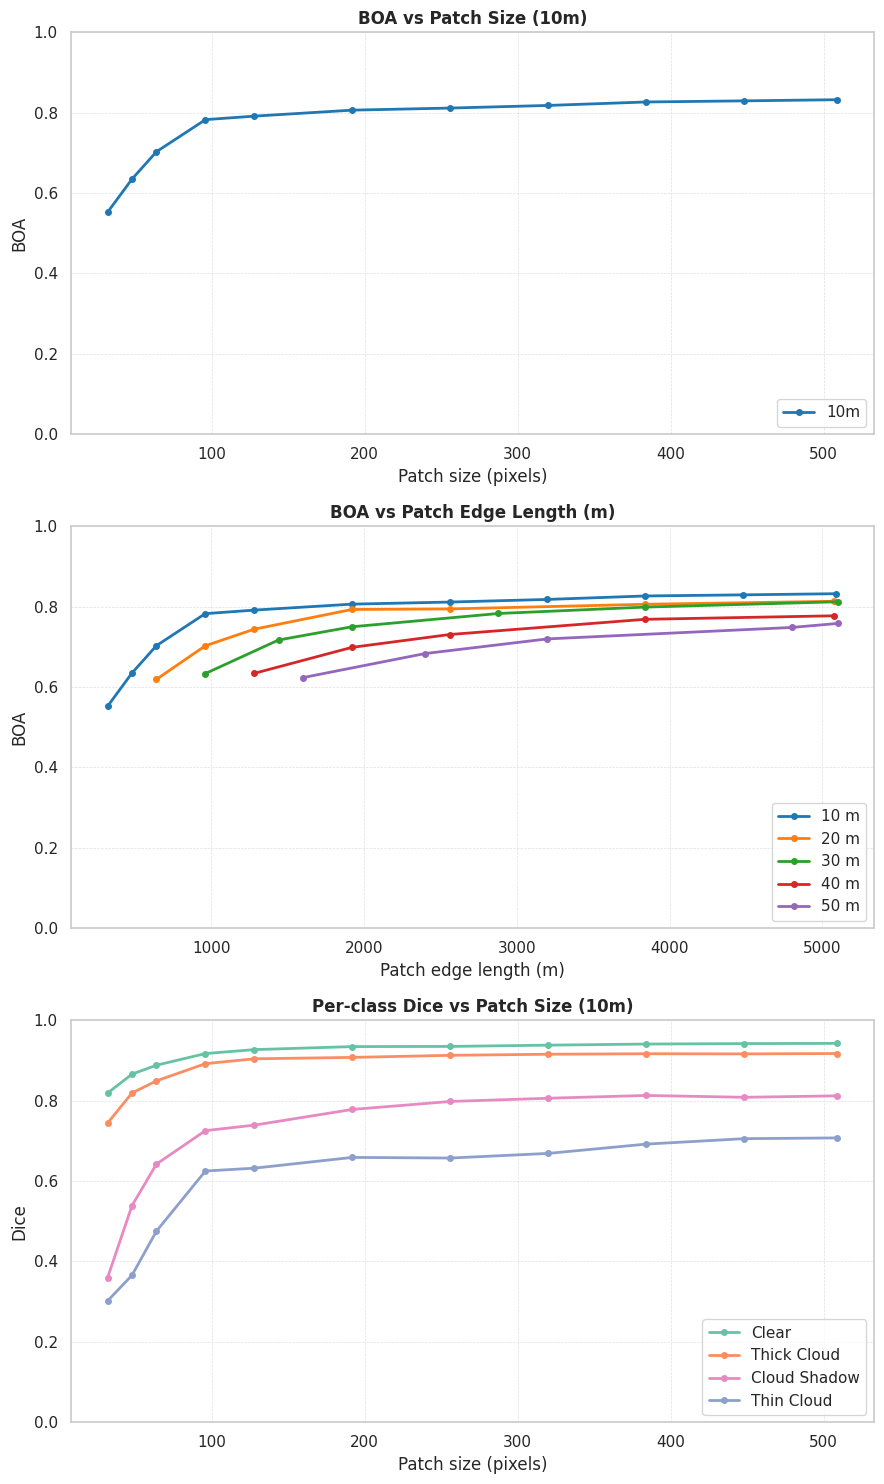

In [5]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(3, 1, figsize=(9, 15))

resolution_palette = sns.color_palette("tab10", len(results))

# Plot 1: BOA vs pixels (10m only)
ax = axes[0]
res_10m = results[list(results.keys())[0]]
sizes = sorted(res_10m.keys())
boa = [res_10m[s]["boa"] for s in sizes]
ax.plot(sizes, boa, "o-", color=resolution_palette[0], lw=2, label="10m", markersize=4)
ax.set_xlabel("Patch size (pixels)")
ax.set_ylabel("BOA")
ax.set_title("BOA vs Patch Size (10m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Plot 2: BOA vs patch edge length (all resolutions)
ax = axes[1]
for i, (res_name, res_results) in enumerate(results.items()):
    sizes = sorted(res_results.keys())
    base_res = int(res_name.replace(" m", "").replace("m", ""))
    edge_m = [s * base_res for s in sizes]
    boa = [res_results[s]["boa"] for s in sizes]
    ax.plot(
        edge_m,
        boa,
        "o-",
        color=resolution_palette[i],
        lw=2,
        label=res_name,
        markersize=4,
    )
ax.set_xlabel("Patch edge length (m)")
ax.set_ylabel("BOA")
ax.set_title("BOA vs Patch Edge Length (m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Plot 3: Per-class Dice at 10m (different palette, legend ordered by score)
ax = axes[2]
class_palette = sns.color_palette("Set2", len(CLASS_NAMES))
sizes = sorted(res_10m.keys())
legend_order = [0, 1, 3, 2]  # Clear, Thick Cloud, Cloud Shadow, Thin Cloud
class_list = list(CLASS_NAMES.values())
for j in legend_order:
    class_name = class_list[j]
    dice_vals = [res_10m[s]["dice_per_class"][class_name] for s in sizes]
    ax.plot(
        sizes,
        dice_vals,
        "o-",
        color=class_palette[j],
        lw=2,
        label=class_name,
        markersize=4,
    )
ax.set_xlabel("Patch size (pixels)")
ax.set_ylabel("Dice")
ax.set_title("Per-class Dice vs Patch Size (10m)", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
docs_plot = Path("..") / "docs" / "_static" / "spatial_context.png"
docs_plot.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(docs_plot, dpi=150, bbox_inches="tight")
print(f"Written: {docs_plot}")

plt.show()

sns.reset_defaults()

## 5. Export results

Save all metrics to JSON for use in documentation. Each row includes the patch size, resolution, context margin in pixels and metres, and all computed metrics.

In [6]:
export: dict = {
    "fingerprint": {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "omnicloudmask_version": omnicloudmask.__version__,
        "pytorch_version": torch.__version__,
        "dataset": "CloudSEN12 High Test",
        "n_scenes": len(scenes),
        "eval_size": EVAL_SIZE,
    },
    "results": [],
}

for res_name, res_results in results.items():
    for patch_size, metrics in sorted(res_results.items()):
        context_margin = (patch_size - EVAL_SIZE) // 2
        base_res = int(res_name.replace("m", ""))
        export["results"].append(
            {
                "resolution": res_name,
                "resolution_m": base_res,
                "patch_size": patch_size,
                "patch_geo_size_m": patch_size * base_res,
                "eval_size": EVAL_SIZE,
                "context_margin_px": context_margin,
                "context_margin_m": context_margin * base_res,
                **metrics,
            }
        )

out_path = out_dir / "spatial_context.json"
out_path.write_text(json.dumps(export, indent=2) + "\n")
print(f"Saved: {out_path}")
print(f"  {len(export['results'])} result rows")

Saved: results/spatial_context.json
  34 result rows


In [9]:
DOCS_DIR = Path("..") / "docs"

# --- Build docs page ---
resolutions_str = ", ".join(
    f"{int(n.replace(' m', '').replace('m', ''))}m"
    for n in list(RESOLUTION_FACTORS.keys())[1:]
)

# Extract values from results for findings text
res_10m_key = list(results.keys())[0]
res_10m = results[res_10m_key]
max_ps = max(res_10m.keys())
max_boa = {
    res_name: max(m["boa"] for m in res_results.values())
    for res_name, res_results in results.items()
}

lines = [
    "# Spatial Context",
    "",
    "How much surrounding spatial context does OmniCloudMask need to accurately "
    "classify a small area? This page shows the impact of input patch size on "
    "accuracy when only the center 32\u00d732 pixels are evaluated.",
    "",
    "These results are relevant in two situations: when you have deliberately "
    "chosen a small `patch_size` for `predict_from_array` or `predict_from_load_func`, or when your input "
    "scene is small enough that OmniCloudMask automatically reduces the patch "
    "size to match the scene dimensions.",
    "",
    "## Method",
    "",
    f"Evaluated on the CloudSEN12 High test set ({len(scenes)} scenes). "
    "For each scene, center patches of increasing size are extracted and predicted "
    "with OmniCloudMask. Only the center 32\u00d732 pixels of each prediction are "
    "compared against the ground truth label. This isolates the effect of "
    "surrounding context on classification accuracy.",
    "",
    f"The experiment is repeated at simulated {resolutions_str} resolution "
    "(bilinear downsampling of the native 10m Sentinel-2 imagery) to test whether "
    "coarser resolutions require different amounts of spatial context. "
    "Predictions at coarser resolutions are upsampled back to 10m with "
    "nearest-neighbour interpolation so all resolutions are evaluated "
    "against the same 10m ground truth.",
    "",
    "## Metrics",
    "",
    "**BOA (Balanced Overall Accuracy)** is the mean of per-class recall, "
    "averaged across all classes. "
    "Unlike overall accuracy, BOA gives equal weight to each class regardless of "
    "how many pixels it covers, so rare classes like thin cloud and cloud shadow "
    "are not drowned out by the dominant clear class.",
    "",
    "$$BOA = 0.5 \\left( \\frac{TP}{TP + FN} + \\frac{TN}{TN + FP} \\right)$$",
    "",
    "**Dice** (equivalent to F1 score) is reported per class. "
    "This shows which classes benefit most from "
    "additional context.",
    "",
    "$$Dice = \\frac{2TP}{2TP + FP + FN}$$",
    "",
    "## Results",
    "",
    "![Spatial context plot](_static/spatial_context.png)",
    "",
    "## Key findings",
    "",
    f"- **96 pixels is the practical minimum patch size.** "
    f"At 10m resolution, BOA jumps from {res_10m[32]['boa']:.2f} at 32px to "
    f"{res_10m[96]['boa']:.2f} at 96px, capturing the bulk of the accuracy gain. "
    f"Beyond 96px, improvements continue but at a much slower rate "
    f"({res_10m[96]['boa']:.2f} to {res_10m[max_ps]['boa']:.2f} over "
    f"the remaining range up to {max_ps}px). If you are working with small patches, "
    "expanding to at least 96\u00d796 pixels will give the largest improvement per "
    "additional pixel.",
    "",
    "- **Larger patches are always better.** Accuracy never plateaus completely. "
    "Even going from 384px to 509px still adds a small gain. Use the largest "
    "patch your workflow allows.",
    "",
    "- **Higher resolution gives better results for the same ground extent.** "
    "Comparing across resolutions at the same edge length (~5 km), "
    + ", ".join(
        f"{res_name} achieves BOA {boa:.2f}" for res_name, boa in max_boa.items()
    )
    + ". More pixels over the same area means more spatial detail for the model "
    "to work with.",
    "",
    f"- **Thin cloud and cloud shadow benefit most from additional context.** "
    f"At 10m, thin cloud Dice rises from "
    f"{res_10m[32]['dice_per_class']['Thin Cloud']:.2f} at 32px to "
    f"{res_10m[96]['dice_per_class']['Thin Cloud']:.2f} at 96px and "
    f"{res_10m[max_ps]['dice_per_class']['Thin Cloud']:.2f} at {max_ps}px, "
    "more than doubling. Cloud shadow shows a similar pattern "
    f"({res_10m[32]['dice_per_class']['Cloud Shadow']:.2f} to "
    f"{res_10m[96]['dice_per_class']['Cloud Shadow']:.2f} to "
    f"{res_10m[max_ps]['dice_per_class']['Cloud Shadow']:.2f}). "
    "By contrast, clear and thick cloud are already above "
    f"{res_10m[32]['dice_per_class']['Clear']:.2f} and "
    f"{res_10m[32]['dice_per_class']['Thick Cloud']:.2f} respectively at 32px and "
    "gain less from extra context. This makes intuitive sense: thin cloud and shadow are "
    "harder to distinguish from their surroundings without seeing the broader scene.",
    "",
    "- **The model needs pixel context, not just ground distance.** "
    "At the same ground extent, coarser resolutions consistently score lower than "
    "finer ones. This means the model benefits from the spatial detail in "
    "higher-resolution pixels, not just from seeing a wider area. Downsampling to "
    "get more ground coverage is not a substitute for higher-resolution input.",
    "",
    "---",
    "",
    "Results generated with"
    " [`benchmarking/spatial_context.ipynb`]"
    "(https://github.com/DPIRD-DMA/OmniCloudMask/blob/main/benchmarking/spatial_context.ipynb)",
]

docs_page = DOCS_DIR / "spatial-context.md"
docs_page.write_text("\n".join(lines) + "\n")
print(f"Written: {docs_page}")

Written: ../docs/spatial-context.md
